# Real Data #1 — Cross-Cultural Gut Microbiome (Yatsunenko et al.)

This is **real data** from a landmark study (Yatsunenko 2012, *Nature*): stool
16S sequencing from people in the **USA vs Malawi**. 150 people, real bacteria,
real geography — your cross-cultural angle with an actual published dataset.

Same skills as your practice notebooks — now on data nobody made up.
Read → Run (`Shift+Enter`) → Modify → Explain.

## 1. Load

In [ ]:
%pip install -q seaborn

In [2]:
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt, seaborn as sns
df = pd.read_csv("real_gut_usa_malawi.csv")
print(df.shape, "->", df.country.value_counts().to_dict())
df.head(100)

(150, 14) -> {'USA': 129, 'Malawi': 21}


,sample_id,country,Bacteroides,Ruminococcus,Blautia,Prevotella,[Ruminococcus],Bifidobacterium,Parabacteroides,Faecalibacterium,Dialister,Dorea,Lachnospira,Oscillospira
0,USygt25.F.418747,USA,44.551,24.810,7.557,0.018,1.303,2.314,0.942,5.352,0.002,1.957,5.064,1.180
1,USygt27.M.418861,USA,19.562,27.034,18.345,0.012,3.890,0.152,2.428,2.663,0.005,2.383,6.906,2.468
2,USygt52.M.418736,USA,40.396,25.739,7.218,0.007,1.031,2.161,2.191,4.770,0.002,2.446,2.337,2.101
3,TS4.418810,USA,60.790,0.341,8.038,0.010,3.745,2.072,9.551,0.161,3.535,1.526,0.938,2.382
4,USygt11.F.418661,USA,3.700,2.571,8.548,48.186,0.713,1.831,1.624,6.786,7.705,1.877,1.235,0.616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,h147M.1.418531,Malawi,0.080,3.067,2.160,46.282,0.151,13.115,0.173,2.858,5.005,0.264,0.998,0.497
96,TS26.418393,USA,50.332,22.593,9.699,0.027,2.689,0.238,2.300,0.139,0.016,2.178,1.323,1.595
97,USygt3.M.418496,USA,22.622,42.234,4.626,0.033,0.417,0.010,3.392,0.025,0.009,0.644,0.010,2.670
98,USygt16.M.418462,USA,49.050,18.786,3.351,0.011,0.947,0.298,3.085,8.379,8.797,0.360,3.416,0.681


## 2. Note the imbalance
129 USA vs 21 Malawi — **unequal group sizes**, common in real data. Worth
remembering: means are still fine, but tiny groups are noisier.

## 3. The headline finding: Prevotella

In [3]:
for t in ["Prevotella","Bacteroides"]:
    a=df[df.country=="USA"][t]; b=df[df.country=="Malawi"][t]
    _,p=stats.ttest_ind(a,b)
    print(f"{t}: USA={a.mean():.1f}%  Malawi={b.mean():.1f}%  p={p:.1e}")

Prevotella: USA=3.5%  Malawi=44.6%  p=1.0e-37
Bacteroides: USA=30.2%  Malawi=0.6%  p=7.4e-14


### What you see
**Prevotella**: ~4% (USA) vs ~45% (Malawi). **Bacteroides**: the reverse. p-values
are astronomically small (1e-37) — this is one of the most robust findings in the
field, driven by diet (fiber/plant-heavy vs Western). *This* is what a real
signal looks like next to the fake country signal from your practice data.

### EXPLAIN #1

*Why is this p-value so much smaller than anything in the practice notebooks?*

> your answer here

## 4. Plot it

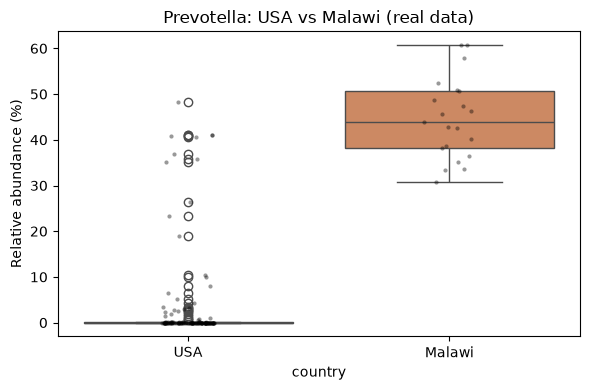

In [4]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x="country", y="Prevotella", hue="country",
            palette=["#4C72B0","#DD8452"], legend=False, ax=ax)
sns.stripplot(data=df, x="country", y="Prevotella", color="black",
              size=3, alpha=0.4, ax=ax)
ax.set_title("Prevotella: USA vs Malawi (real data)")
ax.set_ylabel("Relative abundance (%)")
fig.tight_layout(); plt.show()

### EXPLAIN #2

*Describe the plot. Do the groups overlap, or separate cleanly?*

> your answer here

## 5. Test ALL genera + correct (your Stats #2 skill, real data)

In [5]:
def bh_correct(p):
    p=np.asarray(p); n=len(p); o=np.argsort(p); r=p[o]
    c=np.clip(np.minimum.accumulate((r*n/np.arange(1,n+1))[::-1])[::-1],0,1)
    out=np.empty(n); out[o]=c; return out

genera=[c for c in df.columns if c not in ("sample_id","country")]
raw=[stats.ttest_ind(df[df.country=="USA"][g], df[df.country=="Malawi"][g])[1] for g in genera]
res=pd.DataFrame({"genus":genera,"raw_p":raw,"corrected_p":bh_correct(raw)})
res["significant"]=res.corrected_p<0.05
print(res.sort_values("corrected_p").round(5).to_string(index=False))

           genus   raw_p  corrected_p  significant
      Prevotella 0.00000      0.00000         True
     Bacteroides 0.00000      0.00000         True
           Dorea 0.00000      0.00000         True
  [Ruminococcus] 0.00002      0.00006         True
         Blautia 0.00004      0.00010         True
    Ruminococcus 0.00008      0.00016         True
 Parabacteroides 0.00010      0.00016         True
Faecalibacterium 0.00229      0.00343         True
       Dialister 0.01177      0.01569         True
 Bifidobacterium 0.01530      0.01836         True
    Oscillospira 0.04647      0.05070        False
     Lachnospira 0.16018      0.16018        False


### EXPLAIN #3

*How many genera differ significantly after correction? On real data, does correction wipe them out (like the fake signal did) or do many survive?*

> your answer here

## 6. 🔧 YOUR TURN
Plot a different significant genus (change both `y=` and the title in Section 4).
Predict from the table which ones separate cleanly.

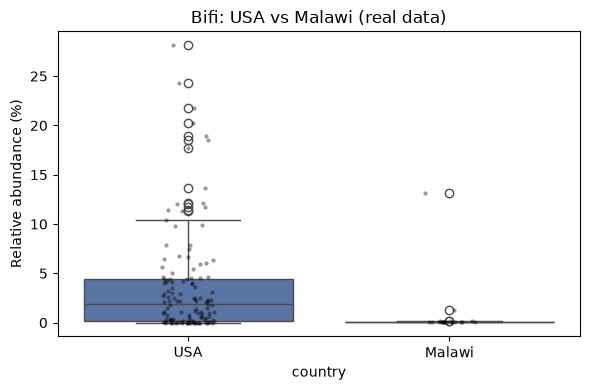

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x="country", y="Bifidobacterium", hue="country",
            palette=["#4C72B0","#DD8452"], legend=False, ax=ax)
sns.stripplot(data=df, x="country", y="Bifidobacterium", color="black",
              size=3, alpha=0.4, ax=ax)
ax.set_title("Bifi: USA vs Malawi (real data)")
ax.set_ylabel("Relative abundance (%)")
fig.tight_layout(); plt.show()

## Done — your first real-data analysis

You loaded a published dataset, reproduced a landmark finding (Prevotella
USA↔Malawi), plotted it, and ran a corrected multi-genus test. This is a genuine
portfolio piece.

**Source:** Yatsunenko et al. 2012, *Nature* 486:222. Data via knights-lab/MLRepo.

Save (Cmd+S). Next: write this up properly, or a new question (age? sex? another cohort?).